# k-means Clustering

## Libraries and settings

In [1]:
# Install opencv-python-headless (neccessary in GitHub Codespaces)
!pip install --upgrade pip
!pip install opencv-python-headless

# Libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Current working directory
print('\nCurrent working directory:', os.getcwd())

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable

Current working directory: /workspaces/data_analytics/Week_10


## 4.) Finding clusters in the apartment data
<a id='section_4'></a>

### Import the apartment data

In [2]:
# Define columns for import
columns = [ 'web-scraper-order',
            'address_raw',
            'rooms',
            'area',
            'luxurious',
            'price',
            'price_per_m2',
            'lat',
            'lon',
            'bfs_number',
            'bfs_name',
            'pop',
            'pop_dens',
            'frg_pct',
            'emp',
            'mean_taxable_income',
            'dist_supermarket']

# Read and select variables
df_orig = pd.read_csv("apartments_data_enriched_cleaned.csv", sep=";", encoding='utf-8')[columns]

# Rename variable 'web-scraper-order' to 'apmt_id'
df_orig = df_orig.rename(columns={'web-scraper-order': 'id'})

# Remove missing values
df = df_orig.dropna()
df.head(5)

# Remove duplicates
df = df.drop_duplicates()

# Remove some 'extreme' values
df = df.loc[(df['price'] >= 1000) & 
            (df['price'] <= 5000)]

print(df.shape)
df.head(5)

(722, 17)


,id,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income,dist_supermarket
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49,0,1441,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,645.652248
1,1693998233-172,"Widacherstrasse 5, 8630 Rüti ZH, ZH",3.0,111,0,2600,23.42,47.252087,8.854919,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,265.102153
2,1693998256-331,"Widenweg 14, 8630 Rüti ZH, ZH",3.0,58,0,1490,25.69,47.253670,8.853993,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,94.401821
3,1693998265-381,"Rain 1, 8630 Rüti ZH, ZH",4.0,118,0,3240,27.46,47.259834,8.851705,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,106.660970
4,1693998276-419,"Bachtelstrasse 24b, 8630 Rüti ZH, ZH",3.0,66,0,1450,21.97,47.266113,8.866872,118,Rüti (ZH),12286,1221.272366,24.841283,5053,65362.04268,974.844209


### Subset of the apartment data frame for k-means clustering

In [4]:
# Define a subset of the data frame for k-means clustering
X3 = df[['rooms',
         'area',
         'price_per_m2',
         'lat',
         'lon',
         'pop_dens',
         'mean_taxable_income']]

### Elbow method showing the optimal k

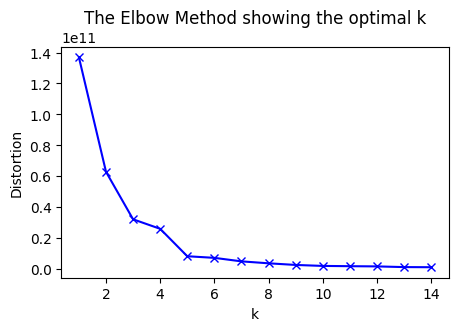

In [5]:
# Sum of squared distances of samples to their closest cluster center
distortions = []

# Range of k's
K = range(1,15)

# Loop to find the optimal k
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X3)
    distortions.append(kmeanModel.inertia_)
    
# Elbow plot
plt.figure(figsize=(5,3))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')

plt.show()

Based on the elbow method applied to the extended feature set (X3), the optimal number of clusters appears to be k = 5, after a weird jump at k = 4.

### Perform k-means clustering on the apartment data

In [6]:
# Number of clusters
k = 5

# Perform k-means clustering
kmeans_apmts = KMeans(n_clusters=k, random_state=42).fit(X3)

# Add the clusters to data frame
X3['cluster'] = kmeans_apmts.predict(X3)

# Show number of apartments per cluster
X3['cluster'].value_counts().sort_values(ascending=False)

cluster
2    389
0    286
4     36
3      8
1      3
Name: count, dtype: int64

#### `Labels`

In [11]:
print(kmeans_apmts.labels_)

[0 0 0 0 0 0 4 4 4 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2
 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 3 3 2 0 0 0 0 0 0 0 0 0 0 2
 2 2 2 2 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4 4 4 4 4 0 0 2 2 2 2 2 2 2 2 0 0 0 2 2 2 2
 2 2 0 0 0 0 0 4 2 2 4 0 0 3 2 2 2 2 2 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 2 

The attribute `labels_` shows the cluster assignment for each apartment, indicating to which cluster each observation belongs.

#### `intertia_`

In [ ]:
print(kmeans_apmts.inertia_)

9910514807.977884 



The attribute `inertia_` represents the within-cluster sum of squared distances and measures how compact the clusters are, with lower values indicating tighter clusters.

#### `cluster_centers_`

In [ ]:
print(kmeans_apmts.cluster_centers_)

[[3.56818182e+00 9.11503497e+01 2.58838811e+01 4.74546924e+01
  8.64107172e+00 1.43893300e+03 6.99666263e+04]
 [3.33333333e+00 9.10000000e+01 2.54066667e+01 4.72706286e+01
  8.64123821e+00 1.20058626e+03 1.30712349e+05]
 [3.25321337e+00 8.24498715e+01 3.63263753e+01 4.73860476e+01
  8.57676662e+00 3.21818630e+03 8.28031780e+04]
 [3.50000000e+00 8.55000000e+01 3.94887500e+01 4.73329000e+01
  8.57867360e+00 1.34991348e+03 1.68895529e+05]
 [3.70833333e+00 1.07833333e+02 2.66566667e+01 4.73423217e+01
  8.58265771e+00 1.52110030e+03 1.05666620e+05]] 



The attribute `cluster_centers_` contains the centroid coordinates of each cluster, representing the average feature values of apartments within each cluster.

#### `feature_names_in_`

In [9]:
print(kmeans_apmts.feature_names_in_)

['rooms' 'area' 'price_per_m2' 'lat' 'lon' 'pop_dens'
 'mean_taxable_income']


And, `feature_names_in_` lists the variables used to construct the clustering model.

### Plot the apartment clusters

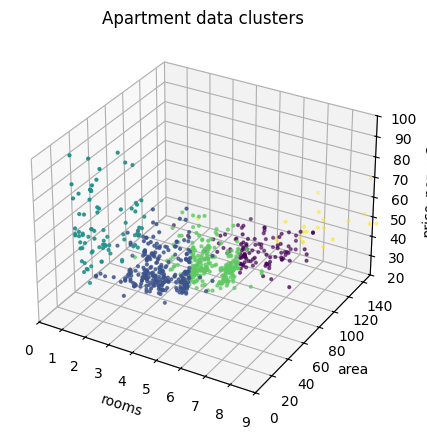

In [25]:
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['rooms'], df['area'], df['price_per_m2'], c=kmeans_apmts.labels_, s=4)

# Set title and axes labels
ax.set_title('Apartment data clusters', fontsize=12)
ax.set_xlabel('rooms', fontsize=10)
ax.set_ylabel('area', fontsize=10)
ax.set_zlabel('price_per_m2', fontsize=10)

# Set axes range
ax.set_xlim([0,9])
ax.set_ylim([0,150])
ax.set_zlim([20,100])

plt.show()

### Calculate the Silhouette Score

In [16]:
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X3)
    score = round(silhouette_score(X3, labels), 4)
    print("k =", k, "--> S. Score:", score)

k = 2 --> S. Score: 0.7938
k = 3 --> S. Score: 0.6446
k = 4 --> S. Score: 0.687
k = 5 --> S. Score: 0.6847
k = 6 --> S. Score: 0.6391
k = 7 --> S. Score: 0.6758
k = 8 --> S. Score: 0.5948
k = 9 --> S. Score: 0.6742
k = 10 --> S. Score: 0.6799
k = 11 --> S. Score: 0.7028
k = 12 --> S. Score: 0.7063
k = 13 --> S. Score: 0.7234
k = 14 --> S. Score: 0.7016


While the elbow method suggests a higher k, the Silhouette Score is maximized at k = 2, indicating that two clusters are the most clearly separated.

# Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [27]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-12-12 23:34:57
Python Version: 3.11.14
-----------------------------------
